# Analytics for analyzing the survey data collected via the survey js questionnaires

In [1]:
#%pip install pymongo python-dotenv pandas
#%pip install neo4j

In [2]:
# importing packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from pymongo import MongoClient
from neo4j import GraphDatabase
import os



## Getting the data from mongo db 

### Connect to MongoDB on `habitvm` via SSH tunnel (using the container IP)

` Host habitvm
HostName 141.76.16.16
User service `

#### 1) Get the current Mongo container IP (on the server)
```bash
ssh habitvm
docker inspect -f '{{range .NetworkSettings.Networks}}{{.IPAddress}}{{end}}' h3-mongo
exit

Replace <MONGO_CONTAINER_IP> with the IP you found in step 1:

` ssh -N -L 27017:<MONGO_CONTAINER_IP>:27017 habitvm `

Can for example look like this

ssh -N -L 27017:172.18.0.3:27017 habitvm

In [3]:
# load repo .env
repo_root = Path("..")  # notebook is in analytics/
load_dotenv(repo_root / ".env")

host = os.getenv("MONGO_HOST", "localhost")
port = int(os.getenv("MONGO_PORT", "27017"))
user_mongo = os.getenv("MONGO_USER")
password_mongo = os.getenv("MONGO_PASSWORD")
db_name = os.getenv("MONGO_DB", "surveyjs")
auth_source = os.getenv("MONGO_AUTH_SOURCE", "admin")

uri = f"mongodb://{user_mongo}:{password_mongo}@{host}:{port}/?authSource={auth_source}"
client = MongoClient(
  uri,
  serverSelectionTimeoutMS=int(os.getenv("MONGO_SERVER_SELECTION_TIMEOUT_MS", "5000")),
  socketTimeoutMS=int(os.getenv("MONGO_SOCKET_TIMEOUT_MS", "5000")),
)

db = client[db_name]
collection = db["results"]

docs = list(collection.find({}))  # all documents right now
len(docs)


print(client.list_database_names())
print(db_name, db.list_collection_names())
print(collection.count_documents({}))


['admin', 'config', 'local', 'surveyjs']
surveyjs ['surveys', 'results']
33


# Getting data from neo4j

To get data from neo4j do:

```
ssh -L 7474:localhost:7474 -L 7687:localhost:7687 service@141.76.16.16

```

In [6]:
uri_neo4j = os.getenv("NEO4J_URI", "bolt://localhost:7687")
user_neo4j = os.getenv("NEO4J_USER", "neo4j")
password_neo4j = os.getenv("NEO4J_PASSWORD")

# Force localhost if env still points to docker hostname
uri_neo4j = uri_neo4j.replace("neo4j:7687", "localhost:7687")

driver = GraphDatabase.driver(uri_neo4j, auth=(user_neo4j, password_neo4j)) # type: ignore

query = """
MATCH (d:hhh__Donor)-[:hhh__donates]->(h:hhh__Habit)-[:hhh__hasBehavior]->(b)
OPTIONAL MATCH (b)-[:hhh__partOf]->(g1)
OPTIONAL MATCH (b)-[:hhh__hasContext]->(c)-[:hhh__partOf]->(g2)
WITH
  coalesce(d.hhh__userId[0], d.hhh__userId) AS user_id,
  [x IN collect(DISTINCT g1) + collect(DISTINCT g2) WHERE x IS NOT NULL] AS groups
UNWIND groups AS g
RETURN DISTINCT
  user_id,
  coalesce([l IN labels(g) WHERE l STARTS WITH 'hhh__Group'][0], 'unknown') AS group_label,
  g.uri AS group_uri
ORDER BY user_id, group_label
"""

with driver.session() as session:
    df_user_groups = pd.DataFrame(session.run(query).data())

df_user_groups.head()

,user_id,group_label,group_uri
0,30fbab8d-4dcc-4472-a8f8-0d1f4fa466ad,hhh__Group2,http://example.com/hhh#ExperimentalSetting-e70...
1,31ed68eb-f002-40e1-922c-3f572738015b,hhh__Group2,http://example.com/hhh#ExperimentalSetting-820...
2,4fae6e8a-6147-4e82-8fe6-938b366fae3d,hhh__Group1,http://example.com/hhh#ExperimentalSetting-61f...
3,63fae9b7-6115-461b-b4bc-a29ed46d58b7,hhh__Group1,http://example.com/hhh#ExperimentalSetting-0f0...
4,63fae9b7-6115-461b-b4bc-a29ed46d58b7,hhh__Group1,http://example.com/hhh#ExperimentalSetting-f3f...


In [7]:
import os
from neo4j import GraphDatabase

uri_neo4j = os.getenv("NEO4J_URI", "bolt://localhost:7687")
user_neo4j = os.getenv("NEO4J_USER", "neo4j")
password_neo4j = os.getenv("NEO4J_PASSWORD")

# Force localhost if env still points to docker hostname
uri_neo4j = uri_neo4j.replace("neo4j:7687", "localhost:7687")

driver = GraphDatabase.driver(uri_neo4j, auth=(user_neo4j, password_neo4j))

# quick connectivity test
with driver.session() as s:
    print(s.run("RETURN 1 AS ok").single()["ok"])


1


## Prepare dataset (prod only) and flatten responses
This section normalizes the nested response payloads, keeps only production submissions, and
treats `-1` as missing.


In [8]:
# Flatten prod responses from docs
rows = []
for d in docs:
    payload = (d.get('data') or {}).get('data') or d.get('json') or {}
    source = 'prod' if (d.get('data') or {}).get('data') else 'test'
    rows.append({
        **payload,
        '_id': str(d.get('_id')),
        'surveyId': d.get('surveyId') or (d.get('data') or {}).get('surveyId'),
        'submittedAt': d.get('submittedAt') or (d.get('data') or {}).get('completedAt'),
        'userId': d.get('userId'),
        'source': source,
    })

df_mongo = pd.DataFrame(rows)
df = df_mongo[df_mongo['source'] == 'prod'].copy()

# Treat -1 as missing for all numeric questionnaire items
sus_cols = [f'sus_q{i}' for i in range(1, 11)]
ueq_cols = [
    'annoying_enjoyable',
    'not_understandable_understandable',
    'creative_dull',
    'easy_to_learn_difficult_to_learn',
    'valuable_inferior',
    'boring_exciting',
    'not_interesting_interesting',
    'unpredictable_predictable',
    'fast_slow',
    'inventive_conventional',
    'obstructive_supportive',
    'good_bad',
    'complicated_easy',
    'unlikable_pleasing',
    'usual_leading_edge',
    'unpleasant_pleasant',
    'secure_not_secure',
    'motivating_demotivating',
    'meets_expectations_does_not_meet_expectations',
    'inefficient_efficient',
    'clear_confusing',
    'impractical_practical',
    'organized_cluttered',
    'attractive_unattractive',
    'friendly_unfriendly',
    'conservative_innovative',
]

all_items = sus_cols + ueq_cols
df_mongo[all_items] = df_mongo[all_items].replace(-1, np.nan).astype(float) #replace -1 with NaN
df_mongo.shape

(33, 53)

In [9]:
df_mongo.columns

Index(['gender', 'country', 'education', 'age', 'weight', 'employment_context',
       'working_hours', 'commute_mode', 'personal_context', 'available_time',
       'relationship_context', 'pet_influence', 'sus_q1', 'sus_q2', 'sus_q3',
       'sus_q4', 'sus_q5', 'sus_q6', 'sus_q7', 'sus_q8', 'sus_q9', 'sus_q10',
       'annoying_enjoyable', 'not_understandable_understandable',
       'creative_dull', 'easy_to_learn_difficult_to_learn',
       'valuable_inferior', 'boring_exciting', 'not_interesting_interesting',
       'unpredictable_predictable', 'fast_slow', 'inventive_conventional',
       'obstructive_supportive', 'good_bad', 'complicated_easy',
       'unlikable_pleasing', 'usual_leading_edge', 'unpleasant_pleasant',
       'secure_not_secure', 'motivating_demotivating',
       'meets_expectations_does_not_meet_expectations',
       'inefficient_efficient', 'clear_confusing', 'impractical_practical',
       'organized_cluttered', 'attractive_unattractive', 'friendly_unfriendly',
 

## SUS scoring (0-100)
Standard SUS: odd items are positive, even items are reversed. Scores are scaled to 0-100.


In [10]:
#If you take a close look at the SUS questions above, you will notice that the statements alternate – odd-numbered ones are positive, and even-numbered ones are negative. 
sus_pos = ['sus_q1', 'sus_q3', 'sus_q5', 'sus_q7', 'sus_q9']
sus_neg = ['sus_q2', 'sus_q4', 'sus_q6', 'sus_q8', 'sus_q10']

sus = df[sus_cols].copy()
sus_score = pd.DataFrame(index=df.index)
sus_score[sus_pos] = sus[sus_pos] - 1
sus_score[sus_neg] = 5 - sus[sus_neg]

sus_total = sus_score.sum(axis=1, skipna=True)
sus_complete = sus_score.notna().sum(axis=1) == 10
sus_total[~sus_complete] = np.nan

df_mongo['sus_score'] = sus_total * 2.5

df_mongo['sus_score'].describe()

count     30.000000
mean      64.583333
std       19.399202
min       30.000000
25%       50.000000
50%       62.500000
75%       85.000000
max      100.000000
Name: sus_score, dtype: float64

## UEQ scoring (6 scales)
UEQ items are mapped from 1-7 to -3..+3. Items where the positive pole is on the left are reversed.


In [21]:
# Items where the positive pole is on the right (negative -> positive)
pos_right = {
    'annoying_enjoyable',
    'not_understandable_understandable',
    'boring_exciting',
    'not_interesting_interesting',
    'unpredictable_predictable',
    'obstructive_supportive',
    'complicated_easy',
    'unlikable_pleasing',
    'usual_leading_edge',
    'unpleasant_pleasant',
    'inefficient_efficient',
    'impractical_practical',
    'conservative_innovative',
}

pos_left = set(ueq_cols) - pos_right

ueq_raw = df[ueq_cols].copy()
ueq_scored = pd.DataFrame(index=df.index)

# Positive on right: 1..7 -> -3..3
ueq_scored[list(pos_right)] = ueq_raw[list(pos_right)] - 4
# Positive on left: reverse (1..7 -> 3..-3)
ueq_scored[list(pos_left)] = 4 - ueq_raw[list(pos_left)]

ueq_scored


,usual_leading_edge,boring_exciting,unpleasant_pleasant,annoying_enjoyable,not_understandable_understandable,not_interesting_interesting,complicated_easy,inefficient_efficient,unlikable_pleasing,obstructive_supportive,...,friendly_unfriendly,inventive_conventional,secure_not_secure,easy_to_learn_difficult_to_learn,fast_slow,valuable_inferior,organized_cluttered,good_bad,motivating_demotivating,clear_confusing
3,-5,-5,-5,-3,-3,-5,-5,-5,-5,-5,...,5,5,5,3,5,3,5,5,5,5
4,-5,3,-5,-3,-3,-5,-5,-5,-5,-5,...,5,5,5,-3,5,-3,5,5,5,5
5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,...,5,5,5,5,5,5,5,5,5,5
6,0,2,0,3,0,0,0,0,0,0,...,0,0,0,2,0,1,0,0,0,0
7,0,-1,2,2,2,0,2,2,0,2,...,3,2,2,2,2,2,3,2,-1,2
8,0,1,0,2,2,1,2,0,0,2,...,0,2,0,2,2,1,-1,2,0,-3
9,1,1,1,3,-3,-1,0,1,1,0,...,1,-3,2,2,0,1,-1,-1,1,2
10,3,2,3,3,3,2,3,3,3,3,...,3,2,3,3,3,3,3,3,0,3
11,1,1,1,2,2,1,2,2,1,2,...,1,2,1,2,1,2,1,2,0,1
12,-5,-5,-5,-3,-5,-5,-5,-5,-5,-5,...,5,5,5,1,5,5,5,5,5,5


In [22]:
ueq_scales = {
    'Attractiveness': [
        'annoying_enjoyable',
        'good_bad',
        'unlikable_pleasing',
        'unpleasant_pleasant',
        'attractive_unattractive',
        'friendly_unfriendly',
    ],
    'Perspicuity': [
        'not_understandable_understandable',
        'easy_to_learn_difficult_to_learn',
        'complicated_easy',
        'clear_confusing',
    ],
    'Efficiency': [
        'inefficient_efficient',
        'fast_slow',
        'impractical_practical',
        'organized_cluttered',
    ],
    'Dependability': [
        'unpredictable_predictable',
        'obstructive_supportive',
        'secure_not_secure',
        'meets_expectations_does_not_meet_expectations',
    ],
    'Stimulation': [
        'boring_exciting',
        'not_interesting_interesting',
        'motivating_demotivating',
        'valuable_inferior',
    ],
    'Novelty': [
        'creative_dull',
        'inventive_conventional',
        'usual_leading_edge',
        'conservative_innovative',
    ],
}

ueq_scale_scores = pd.DataFrame(index=df.index)
for scale, items in ueq_scales.items():
    vals = ueq_scored[items]
    min_items = int(np.ceil(len(items) / 2))
    scores = vals.mean(axis=1, skipna=True)
    scores[vals.notna().sum(axis=1) < min_items] = np.nan
    ueq_scale_scores[scale] = scores

df_mongo = df_mongo.join(ueq_scale_scores)
df_mongo[['Attractiveness','Perspicuity','Efficiency','Dependability','Stimulation','Novelty']].describe()

,Attractiveness,Perspicuity,Efficiency,Dependability,Stimulation,Novelty
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.505556,0.766667,0.616667,0.466667,0.008333,0.125000
std,1.296535,1.361309,1.197579,0.875267,1.416472,1.051989
min,-3.000000,-2.250000,-3.000000,-1.500000,-3.000000,-3.000000
25%,0.000000,0.000000,0.000000,0.000000,-0.437500,0.000000
50%,0.416667,0.625000,0.625000,0.375000,0.000000,0.000000
75%,0.916667,1.687500,1.187500,1.250000,0.687500,0.750000
max,3.000000,3.000000,3.000000,2.000000,3.250000,2.500000


## Visuals
We show SUS distribution, UEQ scale means with 95% CI, and item-level means.


### Visuals for publication

In [ ]:
df_mongo["sus_score"]


0       NaN
1       NaN
2       NaN
3      52.5
4      40.0
5      52.5
6      85.0
7      77.5
8      72.5
9      60.0
10     90.0
11     57.5
12     40.0
13     62.5
14     85.0
15     85.0
16     40.0
17     60.0
18     97.5
19     50.0
20     30.0
21     85.0
22     45.0
23     50.0
24     85.0
25     62.5
26     67.5
27     85.0
28     37.5
29     62.5
30     70.0
31    100.0
32     50.0
Name: sus_score, dtype: float64

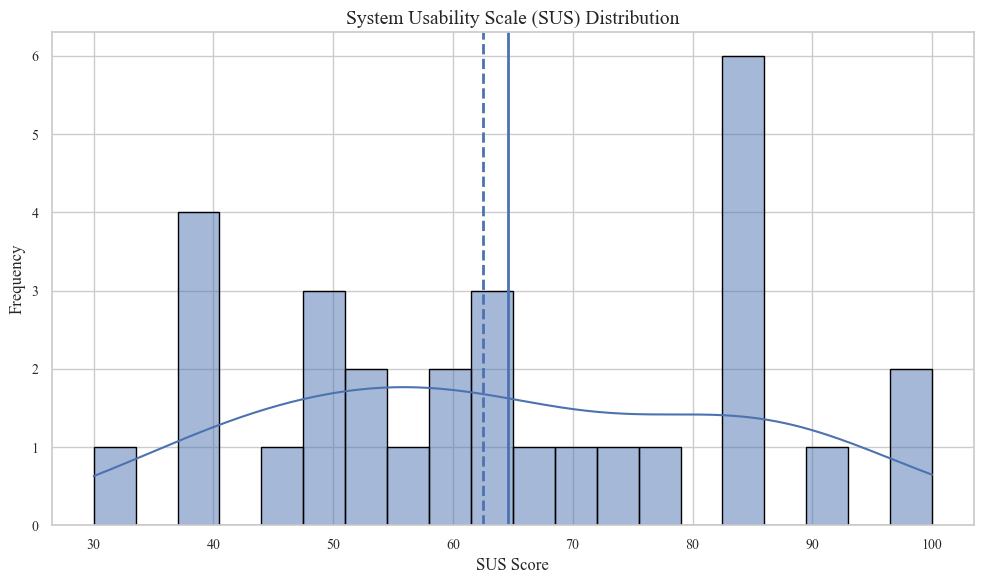

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


# Clean data
data = df_mongo['sus_score'].dropna()

# Compute statistics
mean_val = data.mean()
median_val = data.median()

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

### histogram + KDE for SUS scores
plt.figure(figsize=(10, 6))
sns.histplot(
    df_mongo['sus_score'].dropna(),
    bins=20,
    kde=True,
    #color='skyblue',
    edgecolor='black'
)

#mean line
plt.axvline(
    mean_val,
    linestyle='-',
    linewidth=2,
    label=f"Mean = {mean_val:.1f}"
)

#median line
# Add median line
plt.axvline(
    median_val,
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_val:.1f}"
)




plt.xlabel("SUS Score")
plt.ylabel("Frequency")
plt.title("System Usability Scale (SUS) Distribution")

plt.tight_layout()
plt.show()

### Normal Visuals

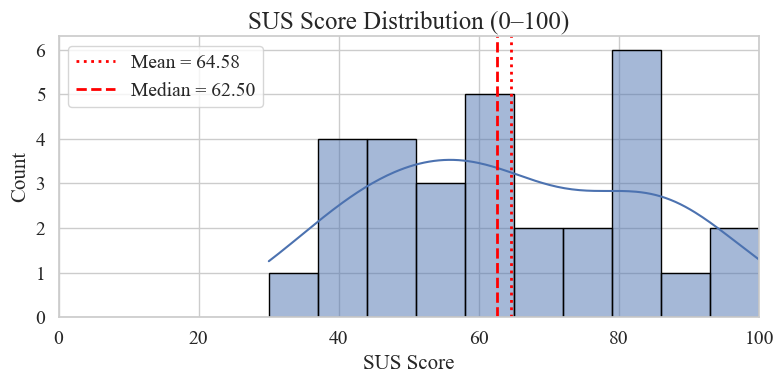

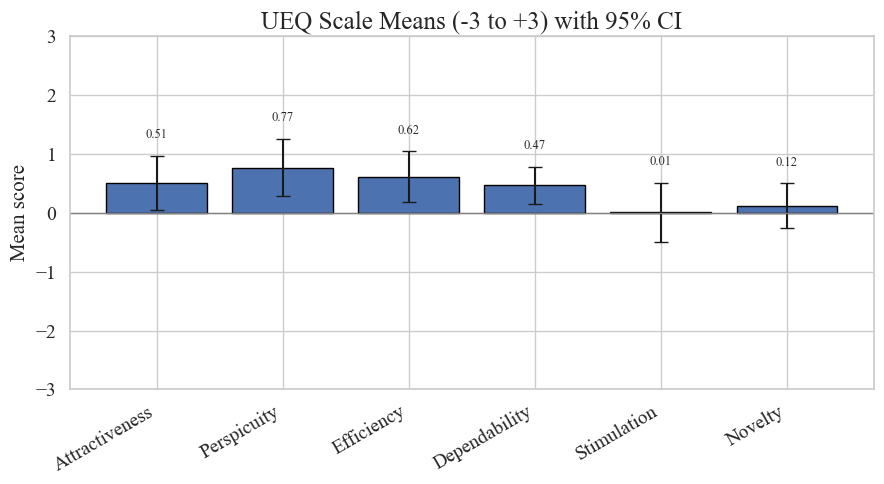

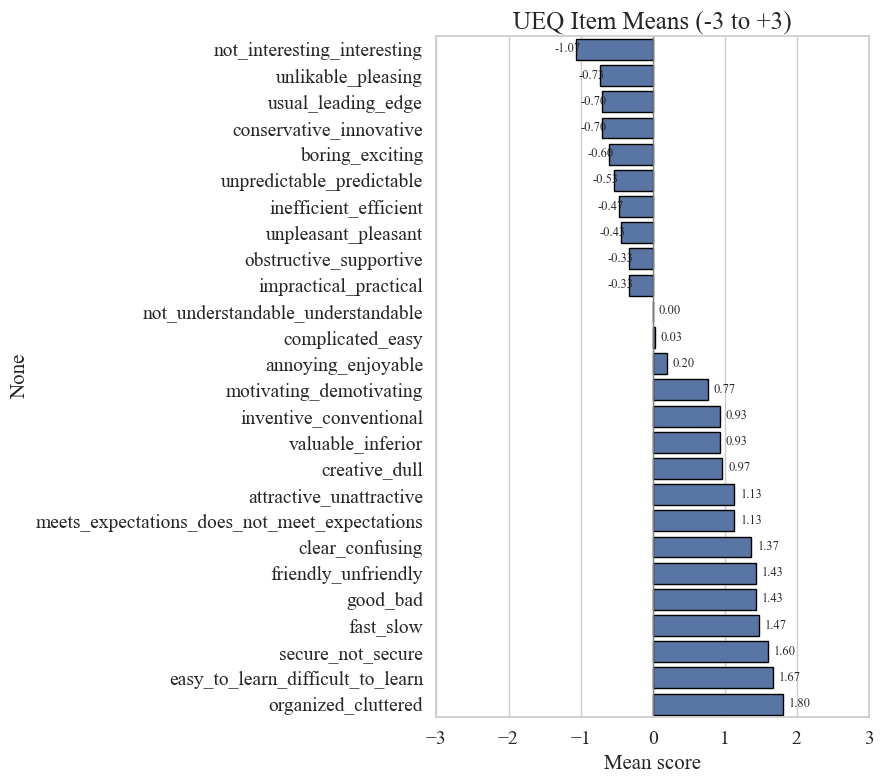

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Consistent publication style
# ----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ----------------------------
# 1) SUS distribution
# ----------------------------
sus_data = df_mongo['sus_score'].dropna()
sus_mean = sus_data.mean()
sus_median = sus_data.median()

plt.figure(figsize=(8, 4))
sns.histplot(
    sus_data,
    bins=10,
    kde=True,
    edgecolor='black'
)

# Distinguishable red lines
plt.axvline(sus_mean, color='red', linestyle=':', linewidth=2, label=f"Mean = {sus_mean:.2f}")
plt.axvline(sus_median, color='red', linestyle='--', linewidth=2, label=f"Median = {sus_median:.2f}")

plt.title('SUS Score Distribution (0–100)')
plt.xlabel('SUS Score')
plt.ylabel('Count')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig("sus.svg", format="svg", bbox_inches="tight")
plt.show()

# ----------------------------
# 2) UEQ scale means with 95% CI
# ----------------------------
scale_stats = []
for scale in ueq_scales.keys():
    s = df_mongo[scale].dropna()
    n = len(s)
    mean = s.mean()
    sd = s.std(ddof=1)
    ci = 1.96 * sd / np.sqrt(n) if n > 1 else np.nan
    scale_stats.append((scale, mean, ci, n))

scale_df = pd.DataFrame(scale_stats, columns=['scale', 'mean', 'ci95', 'n'])

plt.figure(figsize=(9, 5))
bars = plt.bar(
    scale_df['scale'],
    scale_df['mean'],
    yerr=scale_df['ci95'],
    capsize=5,
    edgecolor='black'
)

plt.axhline(0, color='gray', linewidth=1)
plt.ylim(-3, 3)
plt.title('UEQ Scale Means (-3 to +3) with 95% CI')
plt.ylabel('Mean score')
plt.xticks(rotation=30, ha='right')

# Higher label placement (above CI)
offset = 0.25  # increased offset for clarity

for bar, mean_val, ci_val in zip(bars, scale_df['mean'], scale_df['ci95']):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    # place label above error bar (mean + CI + offset)
    if not np.isnan(ci_val):
        y_pos = y + ci_val + offset if y >= 0 else y - ci_val - offset
    else:
        y_pos = y + offset if y >= 0 else y - offset

    plt.text(
        x,
        y_pos,
        f"{mean_val:.2f}",
        ha='center',
        va='bottom' if y >= 0 else 'top',
        fontsize=9
    )

plt.tight_layout()
plt.savefig("ueq_scales.svg", format="svg", bbox_inches="tight")
plt.show()

# ----------------------------
# 3) Item-level means (UEQ)
# ----------------------------
item_means = ueq_scored.mean().sort_values()

plt.figure(figsize=(9, 8))
ax = sns.barplot(
    x=item_means.values,
    y=item_means.index,
    orient='h',
    edgecolor='black'
)

plt.axvline(0, color='gray', linewidth=1)
plt.title('UEQ Item Means (-3 to +3)')
plt.xlabel('Mean score')
plt.xlim(-3, 3)

# Clean label placement
for i, v in enumerate(item_means.values):
    if v >= 0:
        plt.text(v + 0.08, i, f"{v:.2f}", va='center', fontsize=14)
    else:
        plt.text(v - 0.30, i, f"{v:.2f}", va='center', fontsize=14)

plt.tight_layout()
plt.savefig("ueq_items.svg", format="svg", bbox_inches="tight")
plt.show()


In [27]:
import pandas as pd

# Prepare item-level dataframe (since item_means is a Series)
item_df = item_means.reset_index()
item_df.columns = ['item', 'mean']

# Write to Excel
with pd.ExcelWriter("ueq_results.xlsx", engine="openpyxl") as writer:
    scale_df.to_excel(writer, sheet_name="UEQ_scales", index=False)
    item_df.to_excel(writer, sheet_name="UEQ_items", index=False)
    df_mongo['sus_score'].dropna().to_excel(writer, sheet_name="SUS_scores", index=False)

## Interpretation (automatic summary)
Below we summarize the SUS and UEQ results, including a benchmark classification for web sites/services.


In [10]:
# UEQ benchmark for web sites and web services (from handbook)
benchmark = {
    'Attractiveness': [1.75, 1.41, 0.96, 0.44],
    'Perspicuity': [2.07, 1.84, 1.14, 0.65],
    'Efficiency': [1.70, 1.43, 0.98, 0.50],
    'Dependability': [1.70, 1.53, 1.19, 0.81],
    'Stimulation': [1.56, 1.10, 0.69, 0.07],
    'Novelty': [1.12, 0.87, 0.49, -0.22],
}

def benchmark_label(scale, mean):
    if pd.isna(mean):
        return 'n/a'
    excellent, good, above_avg, below_avg = benchmark[scale]
    if mean >= excellent:
        return 'Excellent'
    if mean >= good:
        return 'Good'
    if mean >= above_avg:
        return 'Above average'
    if mean >= below_avg:
        return 'Below average'
    return 'Bad'

summary = scale_df.copy()
summary['benchmark'] = summary.apply(lambda r: benchmark_label(r['scale'], r['mean']), axis=1)
summary


,scale,mean,ci95,n,benchmark
0,Attractiveness,0.505556,0.463959,30,Below average
1,Perspicuity,0.766667,0.487138,30,Below average
2,Efficiency,0.616667,0.428548,30,Below average
3,Dependability,0.466667,0.313210,30,Bad
4,Stimulation,0.008333,0.506878,30,Bad
5,Novelty,0.125000,0.376449,30,Below average


In [12]:
# Text summary for quick reporting
sus_mean = df_mongo['sus_score'].mean()
sus_n = df_mongo['sus_score'].notna().sum()

print('SUS mean: {:.1f} (n={})'.format(sus_mean, sus_n))
print('Rule of thumb: SUS > 68 is above average.')

for _, r in summary.iterrows():
    print('{}: {:.2f} (n={}), {}'.format(r['scale'], r['mean'], int(r['n']), r['benchmark']))


SUS mean: 64.6 (n=30)
Rule of thumb: SUS > 68 is above average.
Attractiveness: 0.51 (n=30), Below average
Perspicuity: 0.77 (n=30), Below average
Efficiency: 0.62 (n=30), Below average
Dependability: 0.47 (n=30), Bad
Stimulation: 0.01 (n=30), Bad
Novelty: 0.12 (n=30), Below average


In [15]:
from IPython.display import Markdown, display

n_total = len(df)
sus_mean = df_mongo['sus_score'].mean()
sus_n = df_mongo['sus_score'].notna().sum()
sus_label = 'above average' if sus_mean > 68 else 'below average'

missing_rate = 1 - ueq_scored.notna().mean().mean()

lines = []
lines.append('### Interpretation')
lines.append('')
lines.append('- Sample size: {} production responses.'.format(n_total))
lines.append('- Missing UEQ item rate: {:.1%} (skipped answers are treated as missing).'.format(missing_rate))
lines.append('- SUS mean: {:.1f} (n={}), which is {} vs the common 68-point benchmark.'.format(sus_mean, sus_n, sus_label))
lines.append('')
lines.append('UEQ scale interpretation (web sites/services benchmark):')
for _, r in summary.iterrows():
    lines.append('- {}: {:.2f} (n={}), {}'.format(r['scale'], r['mean'], int(r['n']), r['benchmark']))

lines.append('')
lines.append('Notes:')
lines.append('- Scale means are on the -3..+3 UEQ scale; values between -0.8 and 0.8 are neutral.')
lines.append('- Larger confidence intervals indicate higher uncertainty (often from small sample sizes).')

display(Markdown('\n'.join(lines)))


### Interpretation

- Sample size: 30 production responses.
- Missing UEQ item rate: 0.0% (skipped answers are treated as missing).
- SUS mean: 64.6 (n=30), which is below average vs the common 68-point benchmark.

UEQ scale interpretation (web sites/services benchmark):
- Attractiveness: 0.51 (n=30), Below average
- Perspicuity: 0.77 (n=30), Below average
- Efficiency: 0.62 (n=30), Below average
- Dependability: 0.47 (n=30), Bad
- Stimulation: 0.01 (n=30), Bad
- Novelty: 0.12 (n=30), Below average

Notes:
- Scale means are on the -3..+3 UEQ scale; values between -0.8 and 0.8 are neutral.
- Larger confidence intervals indicate higher uncertainty (often from small sample sizes).

# Facetted by Groups

In [50]:
# 1) Merge groups into survey dataframe
g = df_user_groups[['user_id', 'group_label']].dropna().drop_duplicates()

# if a user appears in multiple groups, keep first (change if you prefer another rule)
g = g.sort_values(['user_id', 'group_label']).drop_duplicates('user_id', keep='first')

df_plot = df_mongo.copy()
df_plot['userId'] = df_plot['userId'].astype(str)
g['user_id'] = g['user_id'].astype(str)

df_plot = df_plot.merge(g, left_on='userId', right_on='user_id', how='left')
df_plot['group_label'] = df_plot['group_label'].fillna('Unknown')


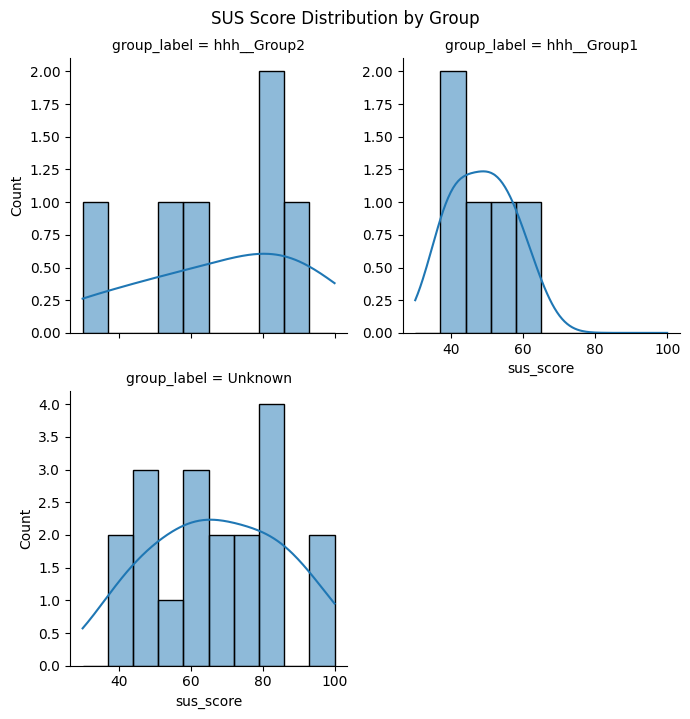

In [51]:
sns.displot(
    data=df_plot.dropna(subset=['sus_score']),
    x='sus_score',
    col='group_label',
    col_wrap=2,
    bins=10,
    kde=True,
    height=3.5,
    facet_kws={'sharex': True, 'sharey': False}
)
plt.suptitle('SUS Score Distribution by Group', y=1.02)
plt.show()


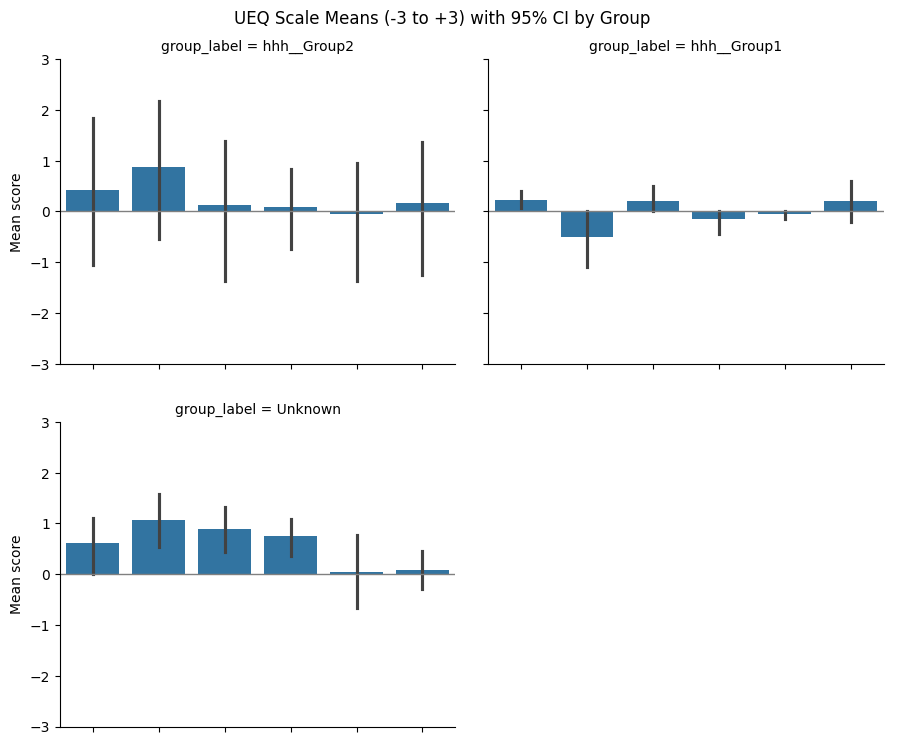

In [52]:
ueq_scale_cols = ['Attractiveness', 'Perspicuity', 'Efficiency',
                  'Dependability', 'Stimulation', 'Novelty']

long_scales = df_plot.melt(
    id_vars=['group_label'],
    value_vars=ueq_scale_cols,
    var_name='scale',
    value_name='score'
).dropna()

g = sns.catplot(
    data=long_scales,
    x='scale', y='score',
    col='group_label', col_wrap=2,
    kind='bar',
    errorbar=('ci', 95),
    height=3.8, aspect=1.2,
    sharey=True
)
g.set_xticklabels(rotation=30, ha='right')
g.set_axis_labels('', 'Mean score')
for ax in g.axes.flatten():
    ax.axhline(0, color='gray', linewidth=1)
    ax.set_ylim(-3, 3)
g.fig.suptitle('UEQ Scale Means (-3 to +3) with 95% CI by Group', y=1.02)
plt.show()


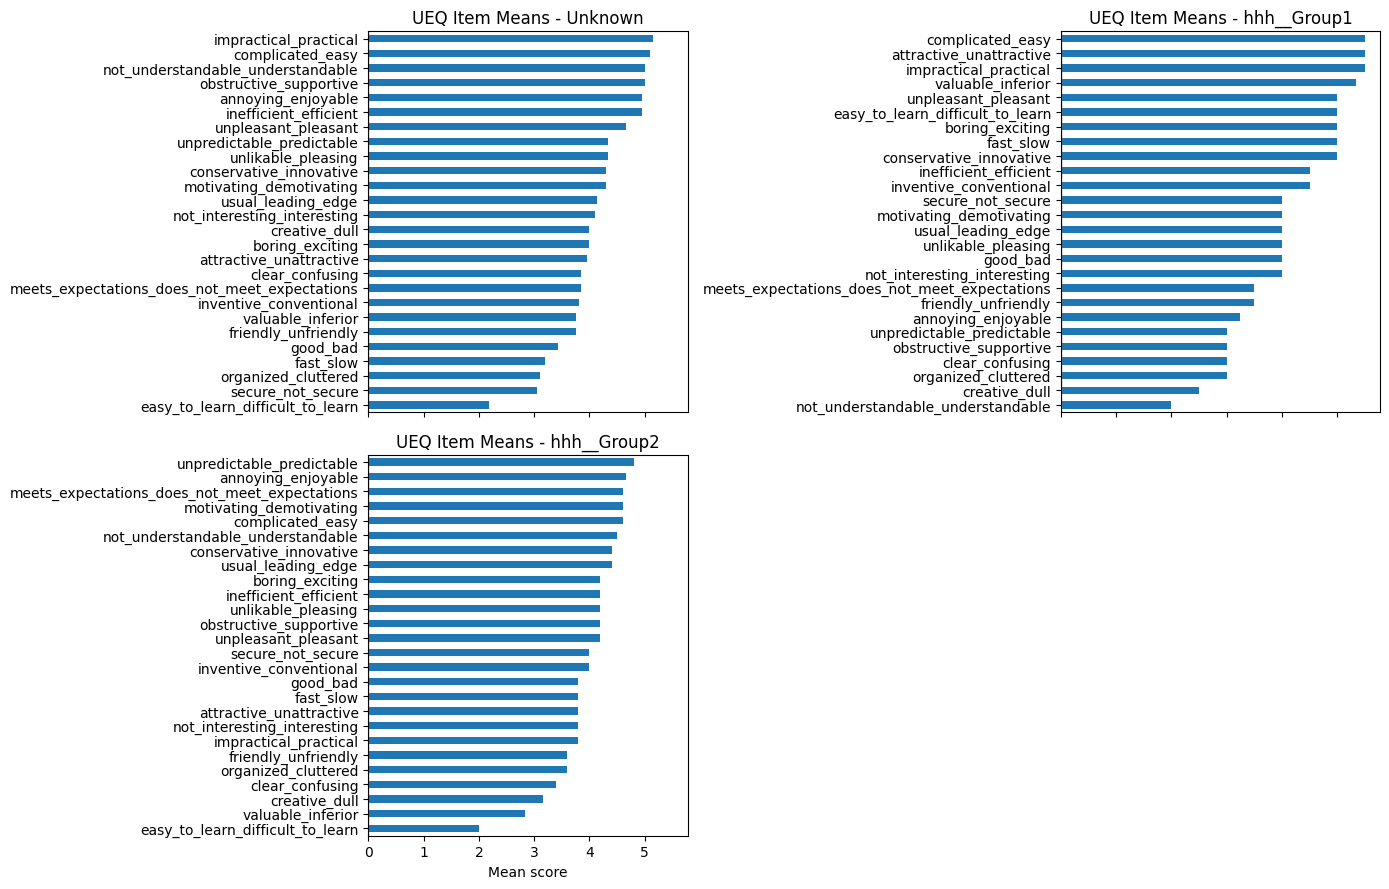

In [53]:
ueq_item_cols = [
    'annoying_enjoyable', 'not_understandable_understandable', 'creative_dull',
    'easy_to_learn_difficult_to_learn', 'valuable_inferior', 'boring_exciting',
    'not_interesting_interesting', 'unpredictable_predictable', 'fast_slow',
    'inventive_conventional', 'obstructive_supportive', 'good_bad',
    'complicated_easy', 'unlikable_pleasing', 'usual_leading_edge',
    'unpleasant_pleasant', 'secure_not_secure', 'motivating_demotivating',
    'meets_expectations_does_not_meet_expectations', 'inefficient_efficient',
    'clear_confusing', 'impractical_practical', 'organized_cluttered',
    'attractive_unattractive', 'friendly_unfriendly', 'conservative_innovative'
]

item_means = (
    df_plot.groupby('group_label')[ueq_item_cols]
    .mean(numeric_only=True)
    .T
)

groups = item_means.columns.tolist()
n = len(groups)
cols = 2
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, grp in enumerate(groups):
    ax = axes[i]
    item_means[grp].sort_values().plot(kind='barh', ax=ax)
    ax.axvline(0, color='gray', linewidth=1)
    ax.set_title(f'UEQ Item Means - {grp}')
    ax.set_xlabel('Mean score')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [54]:

def map_group(lbl):
    if pd.isna(lbl):
        return "Unknown"
    if lbl in ["hhh__Group1", "hhh__Group2", "Group1", "Group2"]:
        return "Group1+2"
    if lbl == "Unknown":
        return "Unknown"
    return "Other"  # optional bucket for Group3/4/etc.

df_plot2 = df_plot.copy()
df_plot2["group_bucket"] = df_plot2["group_label"].apply(map_group)

# If you only want Unknown + Group1+2:
df_plot2 = df_plot2[df_plot2["group_bucket"].isin(["Unknown", "Group1+2"])].copy()

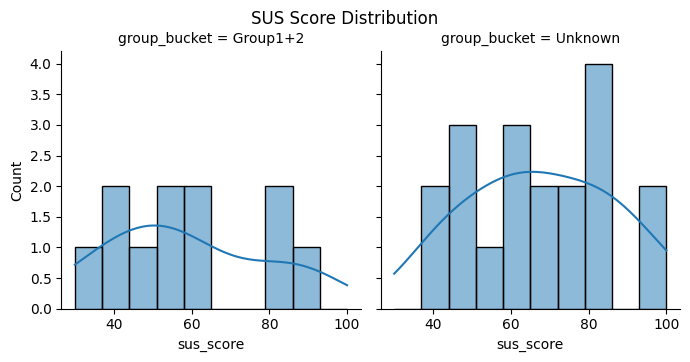

In [55]:
sns.displot(
    data=df_plot2.dropna(subset=["sus_score"]),
    x="sus_score",
    col="group_bucket",
    bins=10,
    kde=True,
    height=3.5
)
plt.suptitle("SUS Score Distribution", y=1.02)
plt.show()


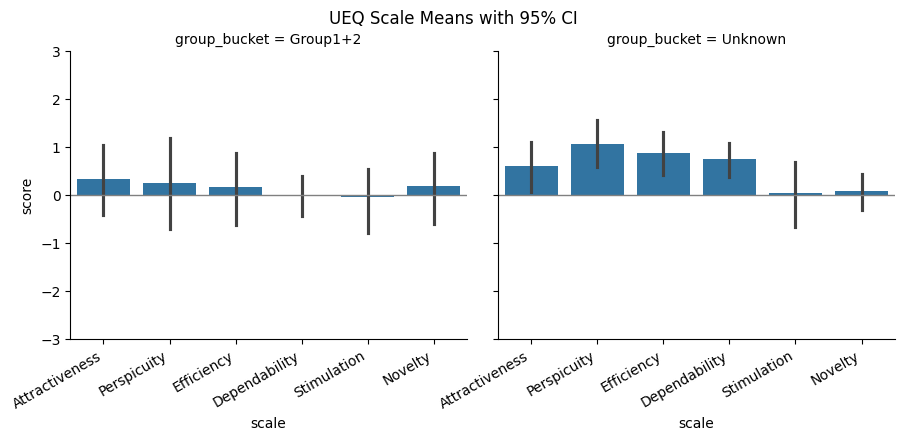

In [56]:
ueq_scale_cols = ["Attractiveness", "Perspicuity", "Efficiency",
                  "Dependability", "Stimulation", "Novelty"]

long_scales = df_plot2.melt(
    id_vars=["group_bucket"],
    value_vars=ueq_scale_cols,
    var_name="scale",
    value_name="score"
).dropna()

g = sns.catplot(
    data=long_scales,
    x="scale", y="score",
    col="group_bucket",
    kind="bar",
    errorbar=("ci", 95),
    height=3.8, aspect=1.2
)
g.set_xticklabels(rotation=30, ha="right")
for ax in g.axes.flatten():
    ax.axhline(0, color="gray", linewidth=1)
    ax.set_ylim(-3, 3)
plt.suptitle("UEQ Scale Means with 95% CI", y=1.02)
plt.show()
